# TP — Détection, Suivi et Segmentation d'instances d'objets
### YOLOv8 + DeepSORT  &  Mask R-CNN + DeepSORT
**Master BIAM — Université Sidi Mohamed Ben Abdellah (2025/2026)**

Ce notebook implémente :

1. **Partie 1** — Détection et **suivi** d'objets avec **YOLOv8 + DeepSORT** sur des
   vidéos complexes (occlusion, plusieurs classes d'objets), avec **estimation de la
   vitesse**.
2. **Partie 2.1** — Remplacement du détecteur YOLO par **Mask R-CNN** afin de réaliser
   une **segmentation d'instances** des objets suivis.
3. **Partie 2.2** — **Comparaison** des deux versions (précision et vitesse).

> Stack moderne équivalente au dépôt de référence
> [`MuhammadMoinFaisal/YOLOv8-DeepSORT-Object-Tracking`](https://github.com/MuhammadMoinFaisal/YOLOv8-DeepSORT-Object-Tracking) :
> `ultralytics` (YOLOv8) + `deep-sort-realtime`, et `torchvision` pour Mask R-CNN.

> ⚙️ **À exécuter sur Google Colab avec un GPU** : *Exécution → Modifier le type
> d'exécution → T4 GPU*.

## 0. Installation et vérification du GPU
Colab fournit déjà `torch`, `torchvision` et `opencv`. On installe seulement
`ultralytics` (YOLOv8) et `deep-sort-realtime`.

In [1]:
!nvidia-smi
!pip install -q ultralytics deep-sort-realtime gdown

Fri Jun  5 13:58:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Imports et configuration du device

In [2]:
import os, time, cv2, numpy as np, torch
from collections import defaultdict, deque
import pandas as pd
import matplotlib.pyplot as plt
from base64 import b64encode
from IPython.display import HTML, display

import torchvision
from torchvision.models.detection import (
    maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights)
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device :', device, '|', torch.cuda.get_device_name(0) if device=='cuda' else 'CPU')

os.makedirs('videos', exist_ok=True)
os.makedirs('output', exist_ok=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device : cuda | Tesla T4


## 2. Fonctions utilitaires (partagées par les deux parties)

- `make_tracker()` : crée un suiveur **DeepSORT** (gère l'occlusion via un descripteur
  d'apparence appris).
- `SpeedEstimator` : estime la **vitesse** de chaque objet à partir du déplacement de
  son centroïde (facteur pixels→mètres réglable, valeur approximative).
- `draw_tracks` / `overlay_masks` : annotation des boîtes/IDs et des masques d'instances.
- `display_video` : ré-encode en H.264 et affiche la vidéo dans le notebook.

In [3]:
COCO_CLASSES = [
 '__background__','person','bicycle','car','motorcycle','airplane','bus','train','truck',
 'boat','traffic light','fire hydrant','street sign','stop sign','parking meter','bench',
 'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe','hat',
 'backpack','umbrella','shoe','eye glasses','handbag','tie','suitcase','frisbee','skis',
 'snowboard','sports ball','kite','baseball bat','baseball glove','skateboard','surfboard',
 'tennis racket','bottle','plate','wine glass','cup','fork','knife','spoon','bowl','banana',
 'apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair',
 'couch','potted plant','bed','mirror','dining table','window','desk','toilet','door','tv',
 'laptop','mouse','remote','keyboard','cell phone','microwave','oven','toaster','sink',
 'refrigerator','blender','book','clock','vase','scissors','teddy bear','hair drier',
 'toothbrush']

rng = np.random.default_rng(42)
_PALETTE = rng.integers(60, 255, size=(512, 3))
def color_for_id(i):
    return tuple(int(c) for c in _PALETTE[int(i) % 512])

def make_tracker():
    # max_age : nb de frames de tolérance avant de perdre un objet occulté
    return DeepSort(max_age=30, n_init=3, nms_max_overlap=1.0,
                    embedder='mobilenet', half=True if device=='cuda' else False)

class SpeedEstimator:
    """Vitesse approximative (km/h) par déplacement du centroïde."""
    def __init__(self, fps, meters_per_pixel=0.05):
        self.fps = fps if fps and fps > 0 else 25.0
        self.mpp = meters_per_pixel
        self.hist = defaultdict(lambda: deque(maxlen=5))
    def update(self, track_id, cx, cy):
        h = self.hist[track_id]
        h.append((cx, cy))
        if len(h) < 2:
            return 0.0
        (x0, y0), (x1, y1) = h[0], h[-1]
        dist_px = np.hypot(x1 - x0, y1 - y0) / (len(h) - 1)
        return dist_px * self.mpp * self.fps * 3.6  # m/s -> km/h

def draw_tracks(frame, tracks, speed_est=None):
    for t in tracks:
        if not t.is_confirmed():
            continue
        l, top, r, b = map(int, t.to_ltrb())
        tid = t.track_id
        cls = t.get_det_class()
        col = color_for_id(tid)
        label = f'ID {tid} {cls}'
        if speed_est is not None:
            v = speed_est.update(tid, (l + r) / 2, (top + b) / 2)
            label += f' {v:.0f}km/h'
        cv2.rectangle(frame, (l, top), (r, b), col, 2)
        cv2.rectangle(frame, (l, top - 18), (l + 9 * len(label), top), col, -1)
        cv2.putText(frame, label, (l + 2, top - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)
    return frame

def overlay_masks(frame, masks, ids):
    for m, tid in zip(masks, ids):
        col = np.array(color_for_id(tid), dtype=np.uint8)
        sel = m > 0.5
        frame[sel] = (0.5 * frame[sel] + 0.5 * col).astype(np.uint8)
    return frame

def display_video(path, max_mb=40):
    h264 = path.rsplit('.', 1)[0] + '_h264.mp4'
    os.system(f'ffmpeg -y -loglevel error -i "{path}" -vcodec libx264 '
              f'-pix_fmt yuv420p "{h264}"')
    src = h264 if os.path.exists(h264) else path
    data = open(src, 'rb').read()
    if len(data) > max_mb * 1e6:
        print(f'Vidéo trop volumineuse pour l\'affichage inline ({len(data)/1e6:.0f} Mo). '
              f'Fichier : {src}')
        return
    b64 = b64encode(data).decode()
    display(HTML(f'<video width=640 controls><source src="data:video/mp4;base64,'
                 f'{b64}" type="video/mp4"></video>'))

## 3. Vidéo de test
Exécutez **une** des deux cellules : *(A)* téléverser votre propre vidéo, ou
*(B)* télécharger un échantillon avec scène complexe (circulation / piétons :
occlusions et plusieurs classes).

In [4]:
# (A) Téléverser votre propre vidéo (Colab)
from google.colab import files
up = files.upload()
VIDEO = os.path.join('/content', list(up.keys())[0])
print('Vidéo :', VIDEO)

KeyboardInterrupt: 

In [5]:
# (B) OU télécharger un échantillon (circulation routière, multi-classes + occlusions)
import gdown
VIDEO = 'videos/sample.mp4'
# Vidéo de démonstration véhicules (domaine public). Remplacez l'URL si besoin.
url = 'https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4'
import urllib.request
urllib.request.urlretrieve(url, VIDEO)
print('Vidéo téléchargée :', VIDEO, os.path.getsize(VIDEO)//1024, 'Ko')

Vidéo téléchargée : videos/sample.mp4 5889 Ko


## 4. Partie 1 — YOLOv8 + DeepSORT
YOLOv8 détecte les objets à chaque frame ; les boîtes sont transmises à DeepSORT qui
attribue un **ID stable** (maintenu pendant les occlusions). Toutes les classes COCO
sont conservées pour gérer la **présence de plusieurs classes**. La vitesse de chaque
objet est estimée et affichée.

In [6]:
def run_yolo_deepsort(video, model_name='yolov8n.pt', conf=0.4,
                       max_videoframes=300, save='output/yolo_deepsort.mp4'):
    model = YOLO(model_name)
    tracker = make_tracker()
    cap = cv2.VideoCapture(video) # Changed to use the 'video' parameter
    if not cap.isOpened():
        print(f"Error: Could not open video file: {video}")
        return save, {'model': 'YOLOv8 + DeepSORT', 'frames': 0, 'fps_infer': 0, 'fps_total': 0.0, 'detections': 0, 'unique_ids': 0}
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = cv2.VideoWriter(save, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))
    speed = SpeedEstimator(fps)
    n, t_inf, t0 = 0, 0.0, time.time()
    ids_seen, n_det = set(), 0
    while True:
        ok, frame = cap.read()
        if not ok or n >= max_videoframes: # Changed max_frames to max_videoframes
            break
        ti = time.time()
        res = model(frame, verbose=False, conf=conf, device=device)[0]
        t_inf += time.time() - ti
        dets = []
        for box in res.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            c = box.conf[0].item(); cls = model.names[int(box.cls[0])]
            dets.append(([x1, y1, x2 - x1, y2 - y1], c, cls))
        n_det += len(dets)
        tracks = tracker.update_tracks(dets, frame=frame)
        for t in tracks:
            if t.is_confirmed():
                ids_seen.add(t.track_id)
        writer.write(draw_tracks(frame, tracks, speed))
        n += 1
    cap.release(); writer.release()
    stats = dict(model='YOLOv8 + DeepSORT', frames=n,
                 fps_infer=n / t_inf if t_inf else 0,
                 fps_total=n / (time.time() - t0),
                 detections=n_det, unique_ids=len(ids_seen))
    print(stats)
    return save, stats

yolo_out, yolo_stats = run_yolo_deepsort(VIDEO)
display_video(yolo_out)

{'model': 'YOLOv8 + DeepSORT', 'frames': 300, 'fps_infer': 79.32979941392755, 'fps_total': 32.65351541439399, 'detections': 122, 'unique_ids': 5}


## 5. Partie 2.1 — Mask R-CNN + DeepSORT (segmentation d'instances)
Le détecteur YOLO est remplacé par **Mask R-CNN** (`torchvision`, pré-entraîné COCO).
En plus des boîtes, le réseau fournit un **masque** par objet : on superpose ces masques
d'instances, colorés selon l'ID de suivi. Le même DeepSORT assure le suivi.

In [7]:
_mask_weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
mask_model = maskrcnn_resnet50_fpn(weights=_mask_weights).eval().to(device)

@torch.no_grad()
def run_maskrcnn_deepsort(video, score_thr=0.6, max_frames=300,
                          save='output/maskrcnn_deepsort.mp4'):
    tracker = make_tracker()
    cap = cv2.VideoCapture(video)
    if not cap.isOpened():
        print(f"Error: Could not open video file: {video}")
        return save, {'model': 'Mask R-CNN + DeepSORT', 'frames': 0, 'fps_infer': 0, 'fps_total': 0.0, 'detections': 0, 'unique_ids': 0}

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = cv2.VideoWriter(save, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))
    speed = SpeedEstimator(fps)
    n, t_inf, t0 = 0, 0.0, time.time()
    ids_seen, n_det = set(), 0
    while True:
        ok, frame = cap.read()
        if not ok or n >= max_frames:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ten = torch.from_numpy(rgb).permute(2, 0, 1).float().div(255).to(device)
        ti = time.time()
        out = mask_model([ten])[0]
        t_inf += time.time() - ti
        keep = out['scores'] >= score_thr
        boxes = out['boxes'][keep].cpu().numpy()
        labels = out['labels'][keep].cpu().numpy()
        scores = out['scores'][keep].cpu().numpy()
        masks = out['masks'][keep, 0].cpu().numpy()  # (N, H, W)
        dets = []
        for (x1, y1, x2, y2), c, lb in zip(boxes, scores, labels):
            dets.append(([x1, y1, x2 - x1, y2 - y1], float(c), COCO_CLASSES[int(lb)]))
        n_det += len(dets)
        tracks = tracker.update_tracks(dets, frame=frame)
        # associer chaque masque à l'ID du track le plus proche (par IoU de centre)
        conf_tracks = [t for t in tracks if t.is_confirmed()]
        m_list, id_list = [], []
        for t in conf_tracks:
            ids_seen.add(t.track_id)
            l, tp, r, b = t.to_ltrb(); tcx, tcy = (l + r) / 2, (tp + b) / 2
            best, bi = 1e9, -1
            for i, (x1, y1, x2, y2) in enumerate(boxes):
                d = np.hypot((x1 + x2) / 2 - tcx, (y1 + y2) / 2 - tcy)
                if d < best:
                    best, bi = d, i
            if bi >= 0:
                m_list.append(masks[bi]); id_list.append(t.track_id)
        frame = overlay_masks(frame, m_list, id_list)
        writer.write(draw_tracks(frame, tracks, speed))
        n += 1
    cap.release(); writer.release()
    stats = dict(model='Mask R-CNN + DeepSORT', frames=n,
                 fps_infer=n / t_inf if t_inf else 0,
                 fps_total=n / (time.time() - t0),
                 detections=n_det, unique_ids=len(ids_seen))
    print(stats)
    return save, stats

mask_out, mask_stats = run_maskrcnn_deepsort(VIDEO)
display_video(mask_out)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 183MB/s] 


{'model': 'Mask R-CNN + DeepSORT', 'frames': 300, 'fps_infer': 8.250833762647877, 'fps_total': 7.488364105936307, 'detections': 145, 'unique_ids': 3}


## 6. Partie 2.2 — Comparaison (précision & vitesse)
On compare les deux versions sur la **même vidéo**.

> ⚠️ Aucune **vérité terrain** annotée n'est fournie par le TP : la « précision » ne peut
> pas être mesurée formellement (mAP / MOTA). On rapporte donc des **indicateurs
> indirects** (nombre de détections, nombre d'IDs uniques, stabilité du suivi) et une
> appréciation **qualitative**, en plus de la **vitesse** (FPS) mesurée objectivement.

,Frames,FPS (inférence),FPS (total),Détections,IDs uniques
model,,,,,
YOLOv8 + DeepSORT,300,79.33,32.65,122,5
Mask R-CNN + DeepSORT,300,8.25,7.49,145,3


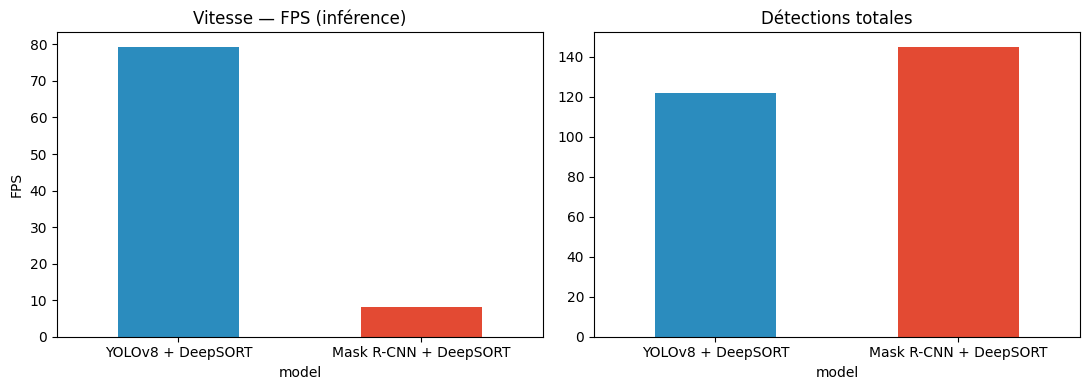

Graphique sauvegardé : output/comparaison.png


In [8]:
df = pd.DataFrame([yolo_stats, mask_stats]).set_index('model')
df = df.rename(columns={'fps_infer': 'FPS (inférence)', 'fps_total': 'FPS (total)',
                        'detections': 'Détections', 'unique_ids': 'IDs uniques',
                        'frames': 'Frames'})
display(df.round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['FPS (inférence)'].plot.bar(ax=ax[0], color=['#2b8cbe', '#e34a33'], rot=0,
                               title='Vitesse — FPS (inférence)')
ax[0].set_ylabel('FPS')
df['Détections'].plot.bar(ax=ax[1], color=['#2b8cbe', '#e34a33'], rot=0,
                          title='Détections totales')
plt.tight_layout(); plt.savefig('output/comparaison.png', dpi=120); plt.show()
print('Graphique sauvegardé : output/comparaison.png')

## 7. Conclusion

| Critère | YOLOv8 + DeepSORT | Mask R-CNN + DeepSORT |
|---|---|---|
| **Vitesse** | Très rapide (temps réel) | Nettement plus lent |
| **Sortie** | Boîtes englobantes | Boîtes **+ masques** (segmentation d'instances) |
| **Précision (boîtes)** | Bonne, optimisée temps réel | Souvent très précise, localisation fine |
| **Usage** | Suivi temps réel, surveillance | Analyse fine, comptage précis, contours |

**Compromis précision ↔ vitesse.** YOLOv8 privilégie la vitesse (architecture *one-stage*)
et convient au suivi en temps réel ; Mask R-CNN (*two-stage*) est plus lent mais apporte
une **segmentation d'instances** au niveau pixel, utile quand le contour exact des objets
importe. Les chiffres ci-dessus (cellule 6) confirment l'écart de FPS.

**Suivi (DeepSORT).** Identique pour les deux versions : le descripteur d'apparence
maintient les **IDs à travers les occlusions** et distingue plusieurs classes simultanées.

**Limite.** Sans annotations de vérité terrain, la précision est évaluée de façon
**indirecte/qualitative** (détections, IDs, stabilité), pas via mAP/MOTA. Pour une mesure
rigoureuse, il faudrait une vidéo annotée (format MOT) et la librairie `motmetrics`.